# Tutorial: Extract CSI For One Position

This notebook shows how to:
1. choose a measurement position
2. resolve that position to a cycle ID
3. extract the complex CSI vector for that cycle
4. plot the phase and power on the antenna plane

A position in the RF xarray is represented by an `experiment_id` and `cycle_id` pair.


In [15]:
# Optional: uncomment when this Jupyter kernel misses the plotting dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml


In [16]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt


def _iter_candidate_tutorial_dirs() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "tutorials",
        cwd / "processing" / "tutorials",
    ]

    # VS Code notebooks expose this variable; it points to the notebook file.
    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        notebook_dir = Path(vscode_notebook).resolve().parent
        candidates.extend(
            [
                notebook_dir,
                notebook_dir / "tutorials",
                notebook_dir / "processing" / "tutorials",
            ]
        )

    ancestor_dirs = [cwd]
    for parent in cwd.parents:
        if parent == Path("/"):
            break
        ancestor_dirs.append(parent)
        if len(ancestor_dirs) >= 3:
            break

    for ancestor in ancestor_dirs:
        candidates.extend(
            [
                ancestor / "tutorials",
                ancestor / "processing" / "tutorials",
            ]
        )
        candidates.extend(ancestor.glob("*/processing/tutorials"))
        candidates.extend(ancestor.glob("*/*/processing/tutorials"))

    seen: set[Path] = set()
    ordered_candidates: list[Path] = []
    for candidate in candidates:
        resolved_candidate = candidate.resolve()
        if resolved_candidate in seen:
            continue
        seen.add(resolved_candidate)
        ordered_candidates.append(resolved_candidate)
    return ordered_candidates


for candidate_dir in _iter_candidate_tutorial_dirs():
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir
        break
else:
    raise ImportError(
        "Could not locate csi_plot_utils.py. Tried these tutorial directories: "
        + ", ".join(str(path) for path in _iter_candidate_tutorial_dirs())
    )

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
PROCESSING_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = PROCESSING_DIR.parent
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)



In [17]:
EXPERIMENT_ID = "EXP003"
DATASET_PATH = None
SELECTED_CYCLE_ID = 100  # Set an integer cycle ID to override the automatic selection.
TARGET_POSITION = None  # Example: {"x": 1.20, "y": 2.40, "z": None}
HEATMAP_MAX_CYCLE_VALUES = csi.DEFAULT_HEATMAP_MAX_CYCLE_VALUES


In [18]:
ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_ID, dataset_path=DATASET_PATH)
antenna_positions = csi.load_antenna_positions()
available_cycles = csi.available_cycle_ids(ds, EXPERIMENT_ID)

print(f"Loaded dataset: {dataset_path}")
print(f"CSI cycles available: {available_cycles.size}")

if TARGET_POSITION is not None:
    nearest = csi.find_nearest_position_cycle(
        ds,
        EXPERIMENT_ID,
        x=TARGET_POSITION["x"],
        y=TARGET_POSITION["y"],
        z=TARGET_POSITION.get("z"),
    )
    SELECTED_CYCLE_ID = int(nearest["cycle_id"])
    print("Selected the nearest recorded cycle for the requested point:")
    print(nearest)
elif SELECTED_CYCLE_ID is None:
    SELECTED_CYCLE_ID = int(available_cycles[0])
    print(f"Using the first cycle with CSI: {SELECTED_CYCLE_ID}")
else:
    SELECTED_CYCLE_ID = int(SELECTED_CYCLE_ID)

position = csi.cycle_position(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID)
print("Rover position for the selected cycle:")
position


Loaded dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
CSI cycles available: 529
Rover position for the selected cycle:


{'experiment_id': 'EXP003',
 'cycle_id': 100,
 'position_available': True,
 'rover_x': 1.5784500732421876,
 'rover_y': 2.4879404296875,
 'rover_z': 0.737845703125,
 'csi_host_count': 42}

## Extract The CSI Vector

The helper below returns one xarray dataset with one entry per hostname. It includes the complex CSI components, derived amplitude and power, and the mapped antenna coordinates.


In [19]:
snapshot = csi.extract_csi_snapshot(
    ds,
    EXPERIMENT_ID,
    SELECTED_CYCLE_ID,
    antenna_positions=antenna_positions,
)

print(
    f"Extracted {snapshot.sizes['hostname']} CSI values "
    f"for experiment {EXPERIMENT_ID}, cycle {SELECTED_CYCLE_ID}"
)
snapshot


Extracted 42 CSI values for experiment EXP003, cycle 100


<xarray.Dataset> Size: 3kB
Dimensions:        (hostname: 42)
Coordinates:
  * hostname       (hostname) <U3 504B 'G05' 'F05' 'E05' ... 'C10' 'B10' 'A10'
Data variables:
    csi_real       (hostname) float64 336B -0.004515 0.00698 ... -0.004537
    csi_imag       (hostname) float64 336B 0.01304 -0.009457 ... 0.001068
    csi_amplitude  (hostname) float64 336B 0.0138 0.01175 ... 0.00422 0.004661
    csi_power_db   (hostname) float64 336B -37.2 -38.6 -43.74 ... -47.49 -46.63
    csi_phase_deg  (hostname) float64 336B 109.1 -53.57 13.82 ... 1.895 166.8
    antenna_x      (hostname) float64 336B 0.35 1.55 2.75 ... 5.15 6.35 7.55
    antenna_y      (hostname) float64 336B 0.66 0.66 0.66 ... 3.66 3.66 3.66
    antenna_z      (hostname) float64 336B 2.4 2.4 2.4 2.4 ... 2.4 2.4 2.4 2.4
Attributes:
    experiment_id:       EXP003
    cycle_id:            100
    position_available:  True
    rover_x:             1.5784500732421876
    rover_y:             2.4879404296875
    rover_z:             0.737845703125
    csi_host_count:      42

## Plot The Selected Position On The Antenna Plane

The red star is the rover location for the selected cycle. The antenna tiles are colored by the extracted CSI values for that same cycle.


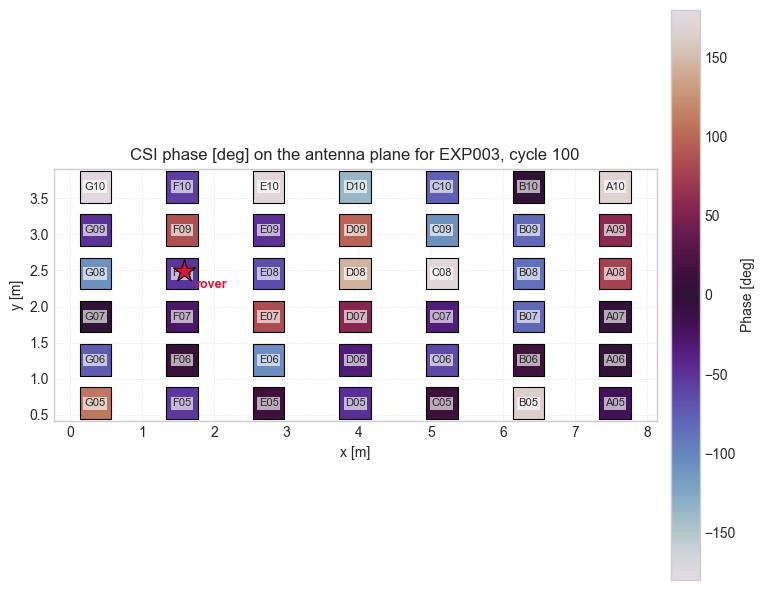

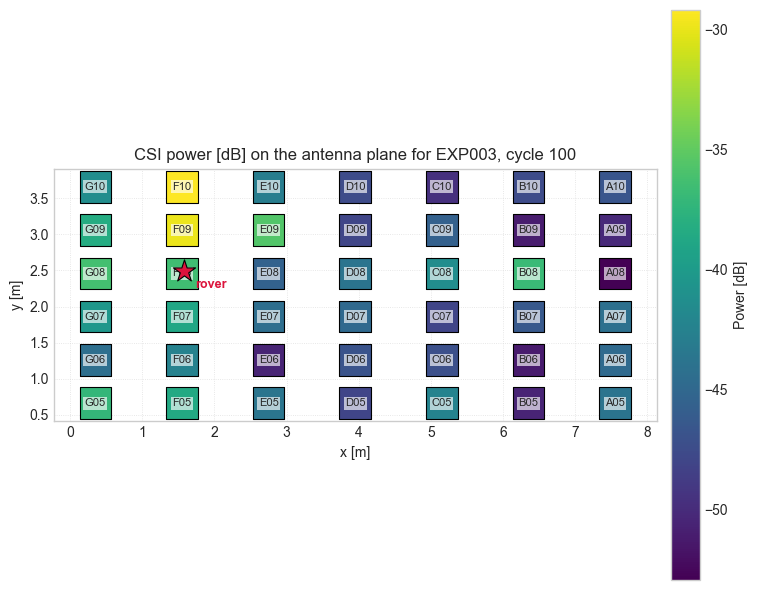

In [20]:
csi.plot_spatial_phase_snapshot(snapshot)
plt.show()

csi.plot_spatial_power_snapshot(snapshot)
plt.show()


## Use The Full Heatmaps To Choose Another Cycle

These plots show the last `HEATMAP_MAX_CYCLE_VALUES` cycle values and are useful when you want to pick a different cycle before extracting another CSI snapshot.


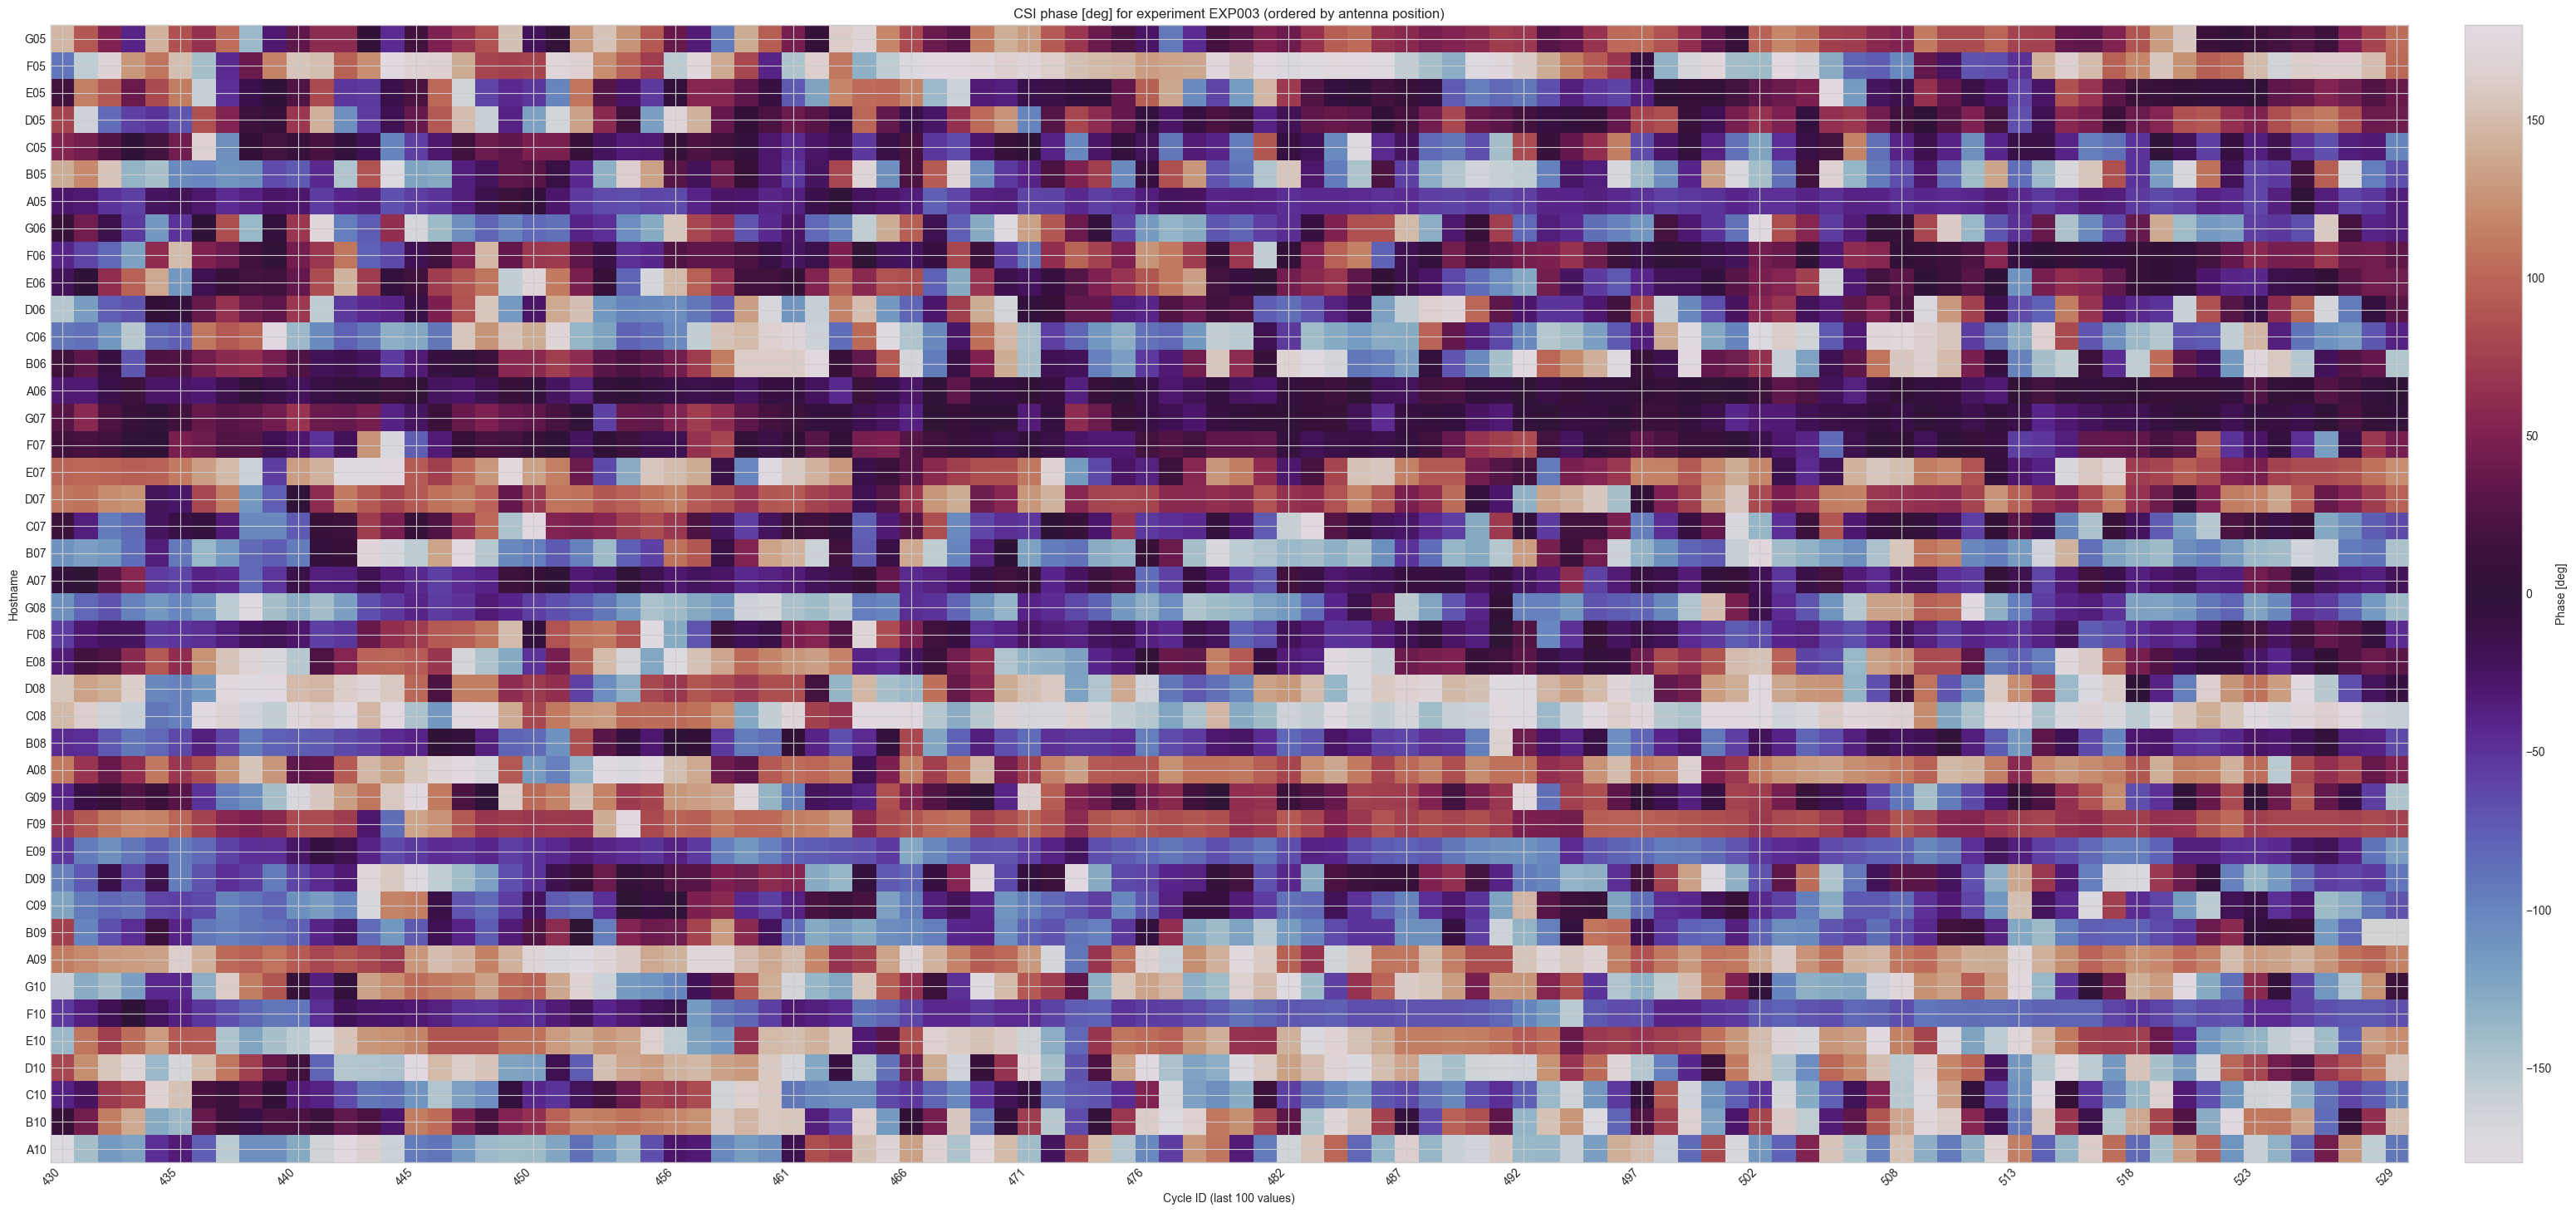

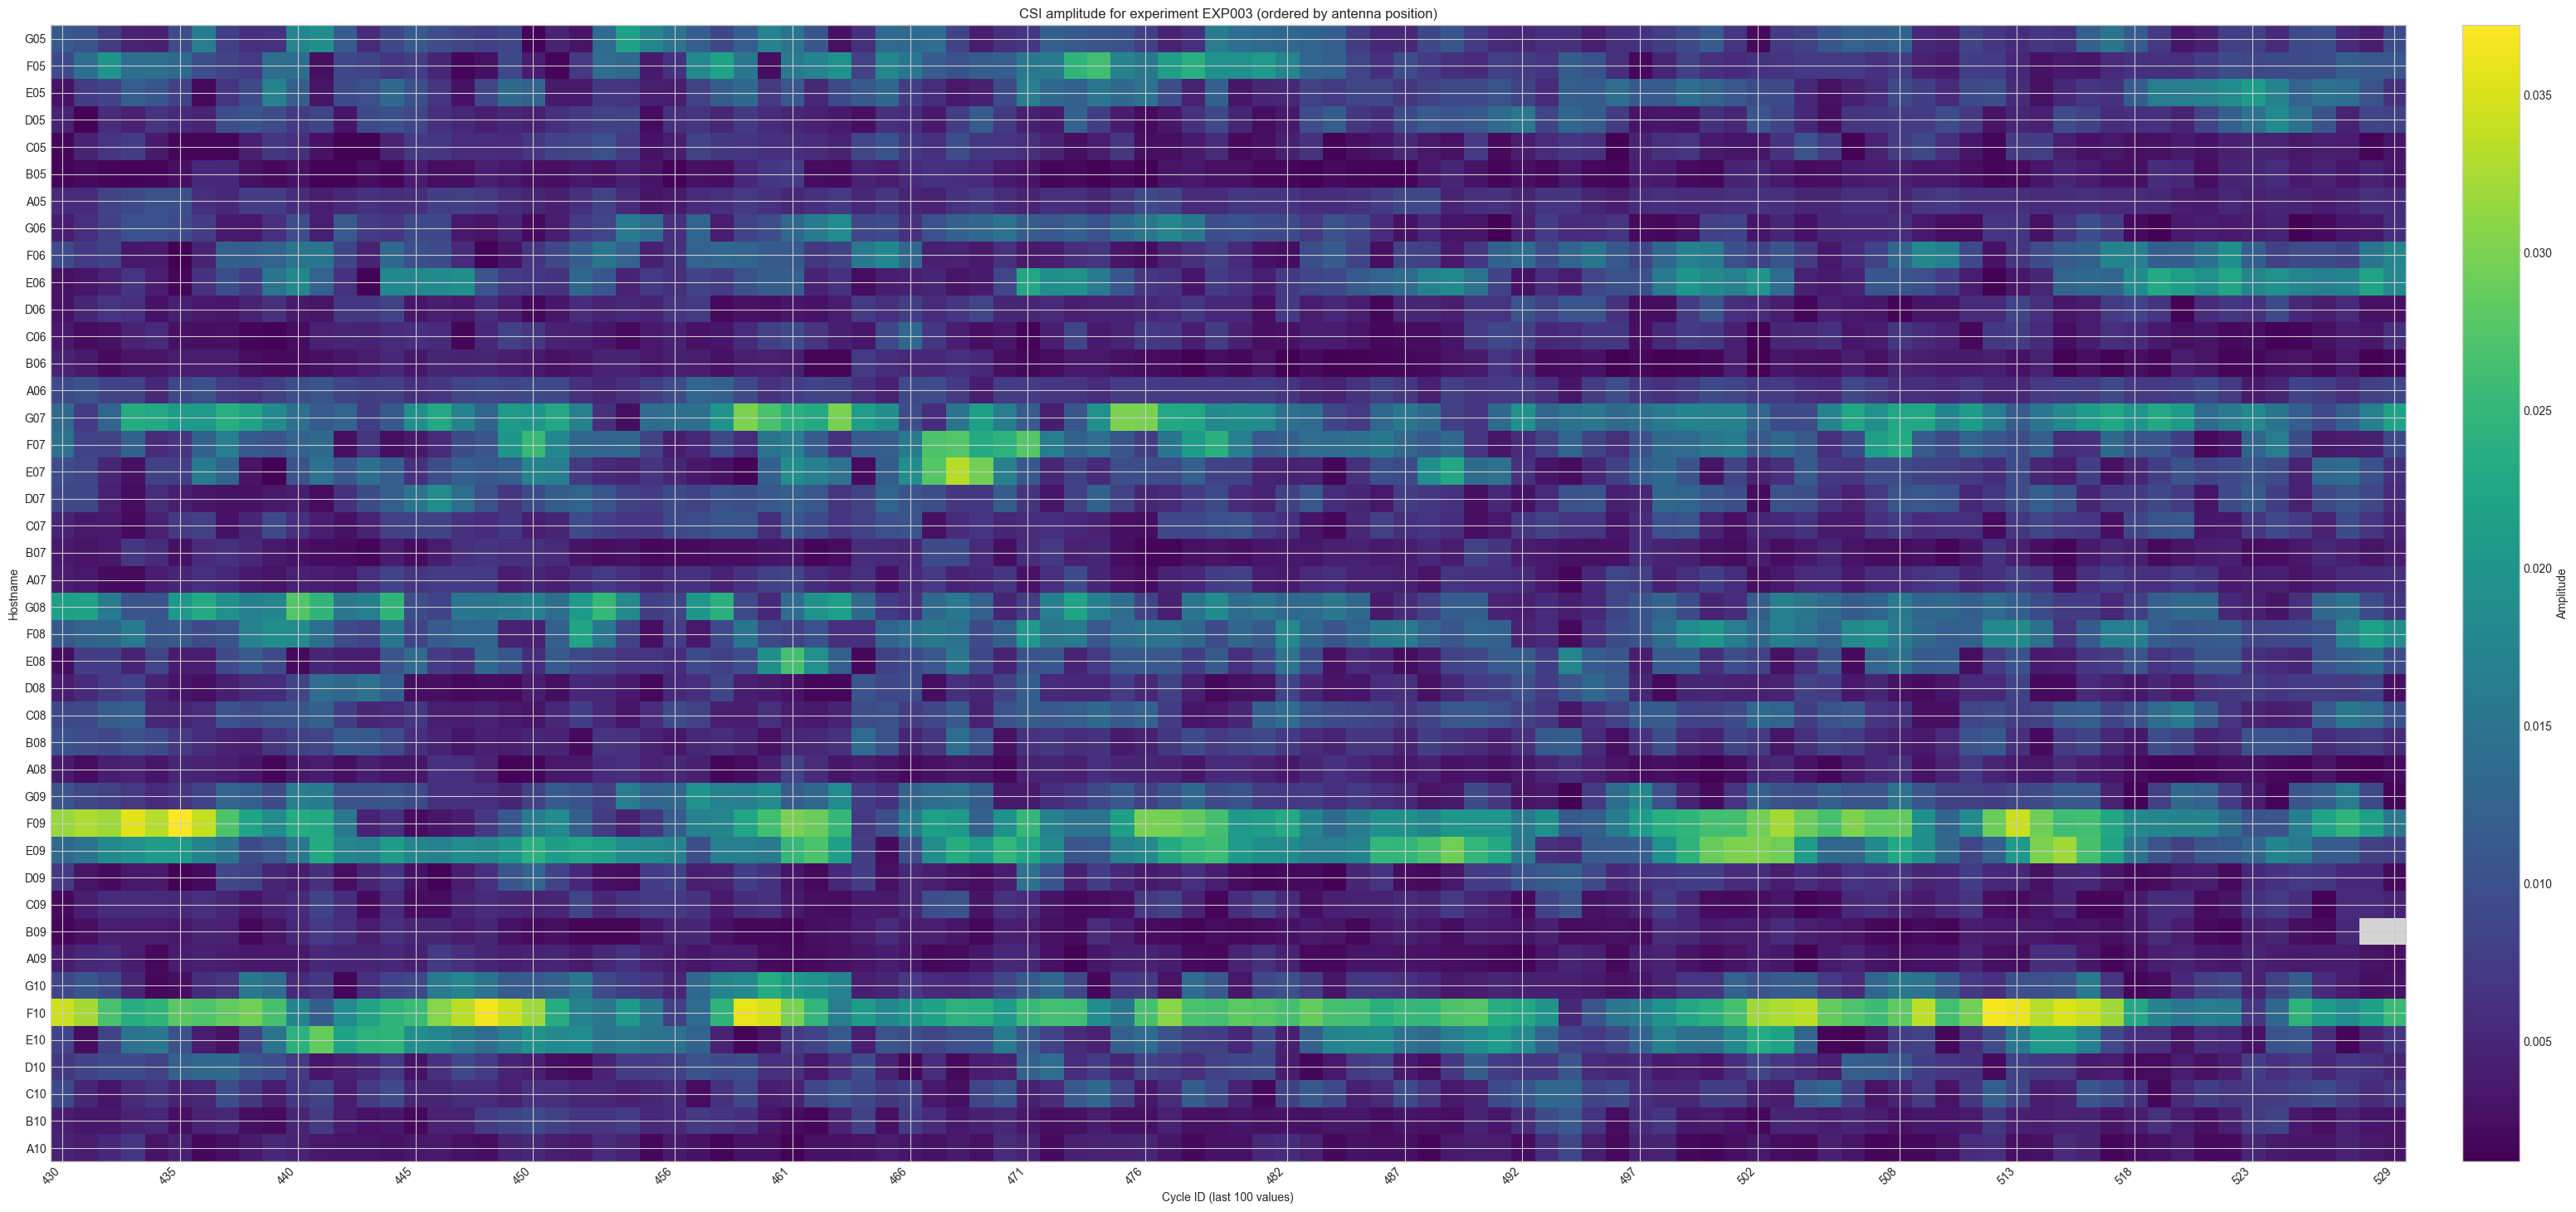

In [21]:
csi.plot_phase_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()

csi.plot_amplitude_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()
